# Notebook 2 -- Feature Engineering

This notebook constructs the complete feature matrix from cleaned OULAD data.
Features are organized into four categories: VLE engagement, assessment performance,
temporal patterns, and registration metadata.

**Objectives:**
- Build VLE engagement features (clicks, activity diversity, forum signals)
- Build assessment features (scores, completion rates, timeliness)
- Build temporal features (weekly trends, engagement slopes)
- Build registration features (timing, unregistration)
- Assemble the complete feature matrix with binary target
- Analyze feature distributions and correlations

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_oulad
from src.feature_builder import (
    build_vle_features,
    build_assessment_features,
    build_temporal_features,
    build_registration_features,
    build_all_features,
)
from src.visualization import (
    apply_style, COLORS,
    plot_feature_distributions,
    plot_correlation_matrix,
)

apply_style()
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load raw data
tables = load_oulad('../data/raw')

  Loaded studentInfo: 32,593 rows, 12 columns
  Loaded studentRegistration: 32,593 rows, 5 columns
  Loaded studentAssessment: 173,912 rows, 5 columns
  Loaded studentVle: 10,655,280 rows, 6 columns
  Loaded assessments: 206 rows, 6 columns
  Loaded vle: 6,364 rows, 6 columns
  Loaded courses: 22 rows, 3 columns

All 7 OULAD tables loaded successfully.


## 2.1 Build Complete Feature Matrix

The `build_all_features` function assembles all feature groups into
a single DataFrame with one row per student-module-presentation.

In [3]:
features = build_all_features(tables)

print(f'\nFeature matrix shape: {features.shape}')
print(f'Target distribution:')
print(f'  Dropout:   {features["is_dropout"].sum():,} ({features["is_dropout"].mean()*100:.1f}%)')
print(f'  Completed: {(1-features["is_dropout"]).sum():,}')

Cleaning base tables...
  studentVle: 10,655,280 rows after cleaning

Building VLE engagement features...
    Merging VLE activity types...
    Computing basic aggregates...
    Computing daily click statistics...
    Computing activity type breakdown...
    Computing activity diversity...
  Done: 29,228 students

Building assessment features...
  Done: 25,843 students

Building temporal features...
    Aggregating weekly clicks...
    Pivoting first 4 weeks...
    Computing engagement slopes (vectorized)...
  Done: 27,886 students

Building registration features...
  Done: 32,593 students

Merging all features...

Feature matrix complete: 32,593 students, 60 features

Feature matrix shape: (32593, 60)
Target distribution:
  Dropout:   17,208 (52.8%)
  Completed: 15,385


In [4]:
# List all numeric features
numeric_features = features.select_dtypes(include=[np.number]).columns.tolist()
# Exclude identifiers and targets
exclude = ['id_student', 'is_dropout', 'completion_status']
model_features = [f for f in numeric_features if f not in exclude]

print(f'\nNumber of model features: {len(model_features)}')
print('\nFeatures:')
for i, f in enumerate(model_features, 1):
    print(f'  {i:2d}. {f}')


Number of model features: 49

Features:
   1. num_of_prev_attempts
   2. studied_credits
   3. age_band_numeric
   4. education_numeric
   5. total_clicks
   6. total_days_active
   7. first_activity_date
   8. last_activity_date
   9. distinct_activities
  10. mean_daily_clicks
  11. max_daily_clicks
  12. std_daily_clicks
  13. activity_span_days
  14. engagement_forumng
  15. engagement_oucontent
  16. engagement_resource
  17. engagement_quiz
  18. engagement_homepage
  19. engagement_subpage
  20. engagement_url
  21. engagement_ouwiki
  22. activity_diversity
  23. average_score
  24. cumulative_score
  25. score_std
  26. completed_assessments
  27. weighted_average_score
  28. total_assessments
  29. completed_assessments_ratio
  30. cma_avg_score
  31. exam_avg_score
  32. tma_avg_score
  33. learning_pace
  34. late_submissions
  35. late_submission_ratio
  36. week_1_clicks
  37. week_2_clicks
  38. week_3_clicks
  39. week_4_clicks
  40. early_engagement_ratio
  41. engage

## 2.2 Feature Statistics

In [5]:
# Summary statistics for key features
key_features = [
    'total_clicks', 'total_days_active', 'distinct_activities',
    'activity_diversity', 'mean_daily_clicks',
    'average_score', 'completed_assessments_ratio',
    'learning_pace', 'late_submission_ratio',
    'engagement_forumng', 'forum_engagement_ratio',
    'module_engagement_rate', 'engagement_slope',
]

available_key = [f for f in key_features if f in features.columns]
print(features[available_key].describe().round(2).to_string())

       total_clicks  total_days_active  distinct_activities  activity_diversity  mean_daily_clicks  average_score  completed_assessments_ratio  learning_pace  late_submission_ratio  engagement_forumng  forum_engagement_ratio  module_engagement_rate  engagement_slope
count      32593.00           32593.00             32593.00            32593.00           32593.00       32593.00                     32593.00       32593.00               32593.00            32593.00                32593.00                32593.00          32593.00
mean        1215.14              55.48                 7.37                1.87              17.08          57.59                         0.54         -18.70                   0.24              244.64                    0.16                    1.00             -0.34
std         1692.60              54.52                 3.50                0.76              12.40          32.93                         0.39          36.76                   0.31              572.0

## 2.3 Feature Distributions by Outcome

Figure saved: ../results/figures/feature_distributions.png


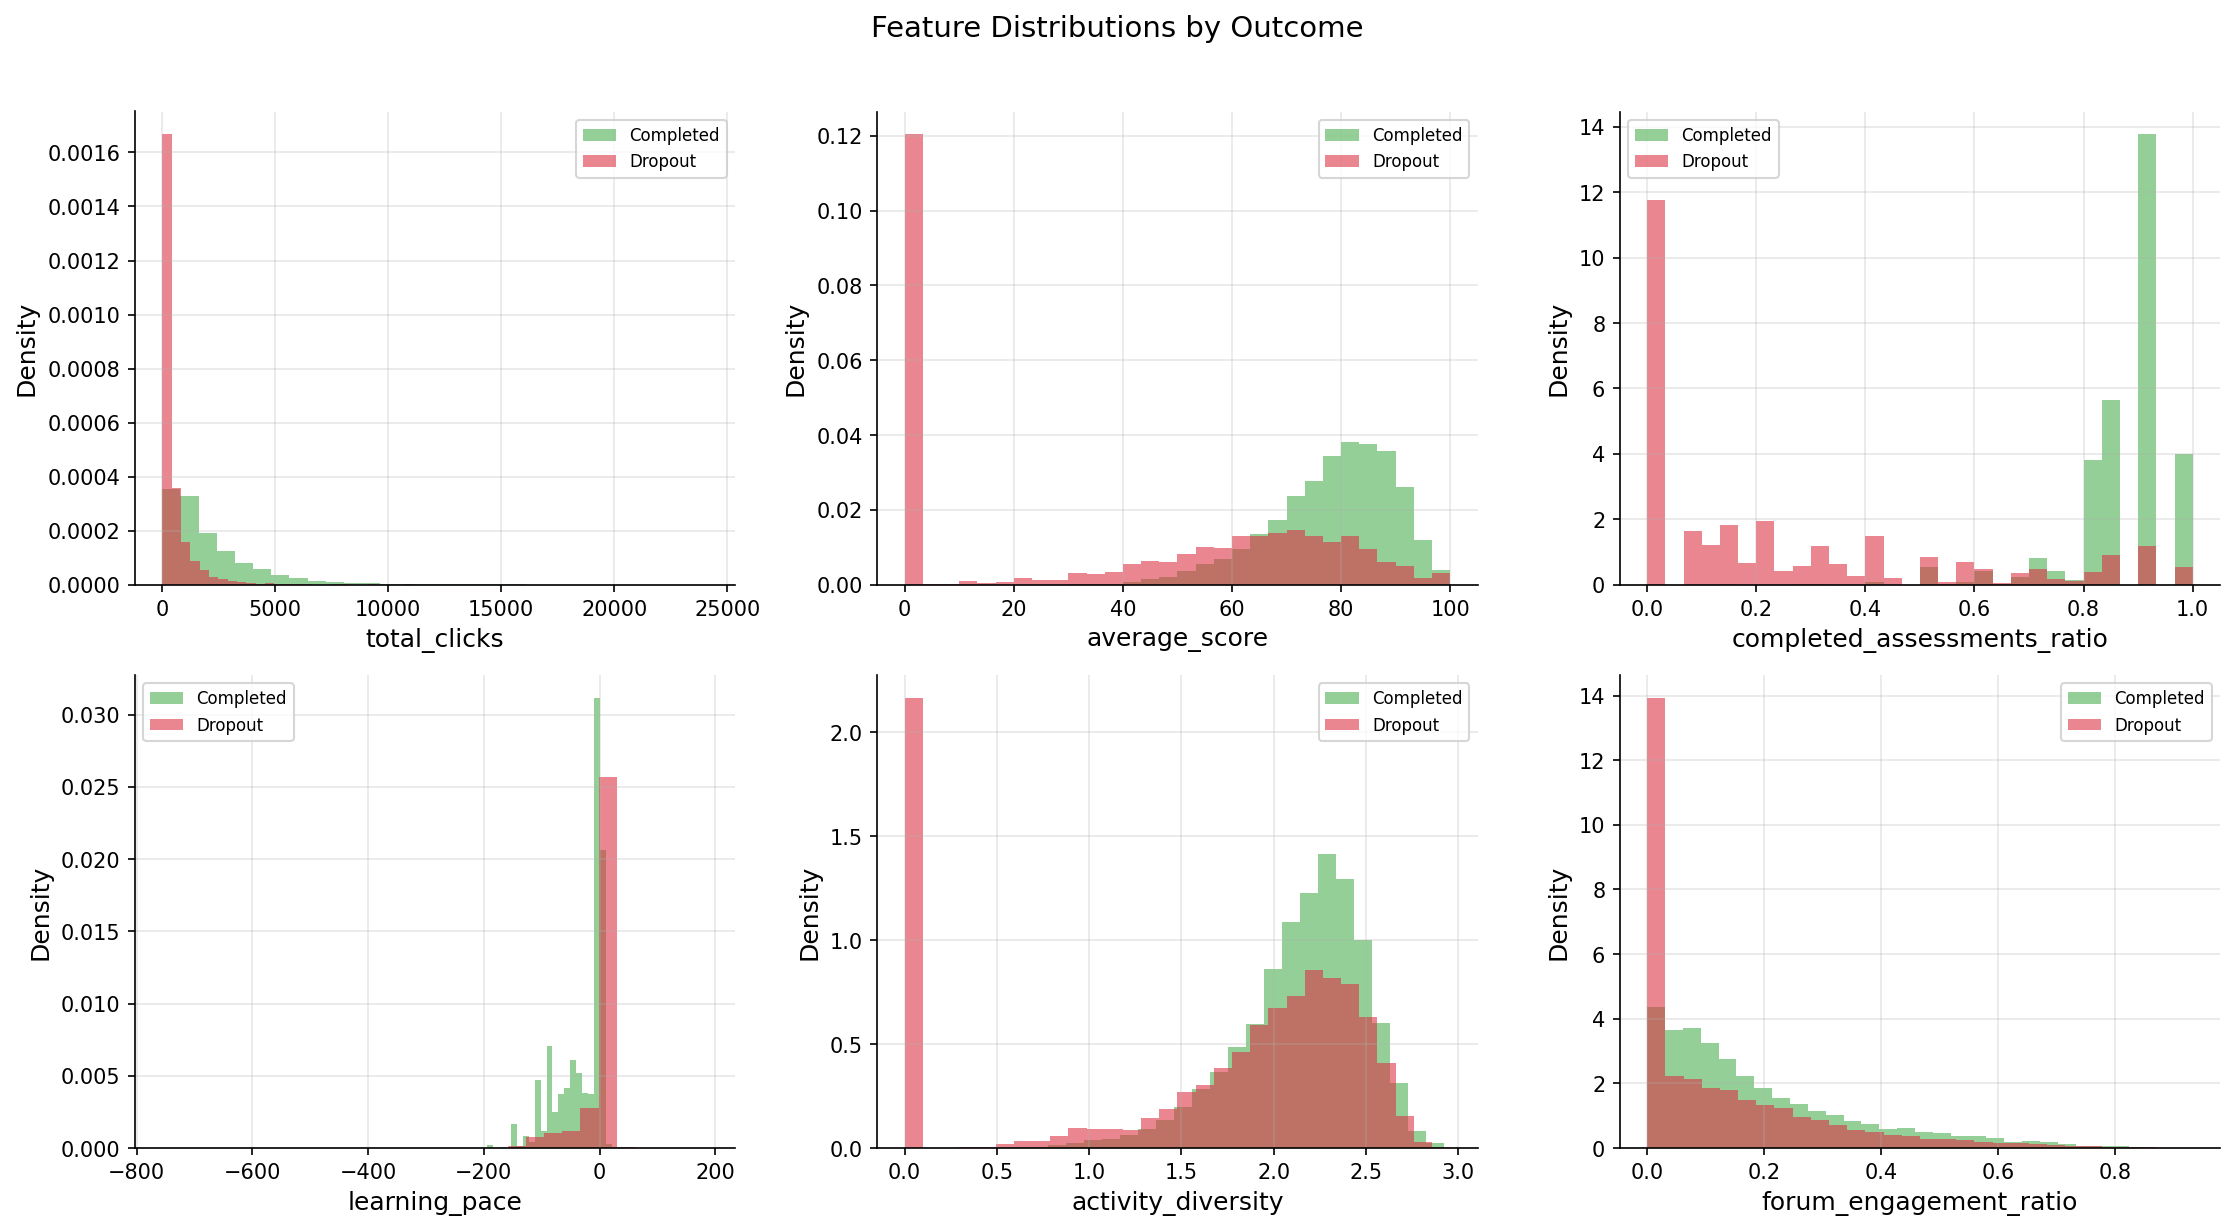

In [6]:
plot_features = [
    'total_clicks', 'average_score', 'completed_assessments_ratio',
    'learning_pace', 'activity_diversity', 'forum_engagement_ratio',
]
available_plot = [f for f in plot_features if f in features.columns]

fig = plot_feature_distributions(
    features, available_plot, target_col='is_dropout',
    save_path='../results/figures/feature_distributions.png'
)
plt.show()

## 2.4 Feature Correlations

Figure saved: ../results/figures/feature_correlations.png


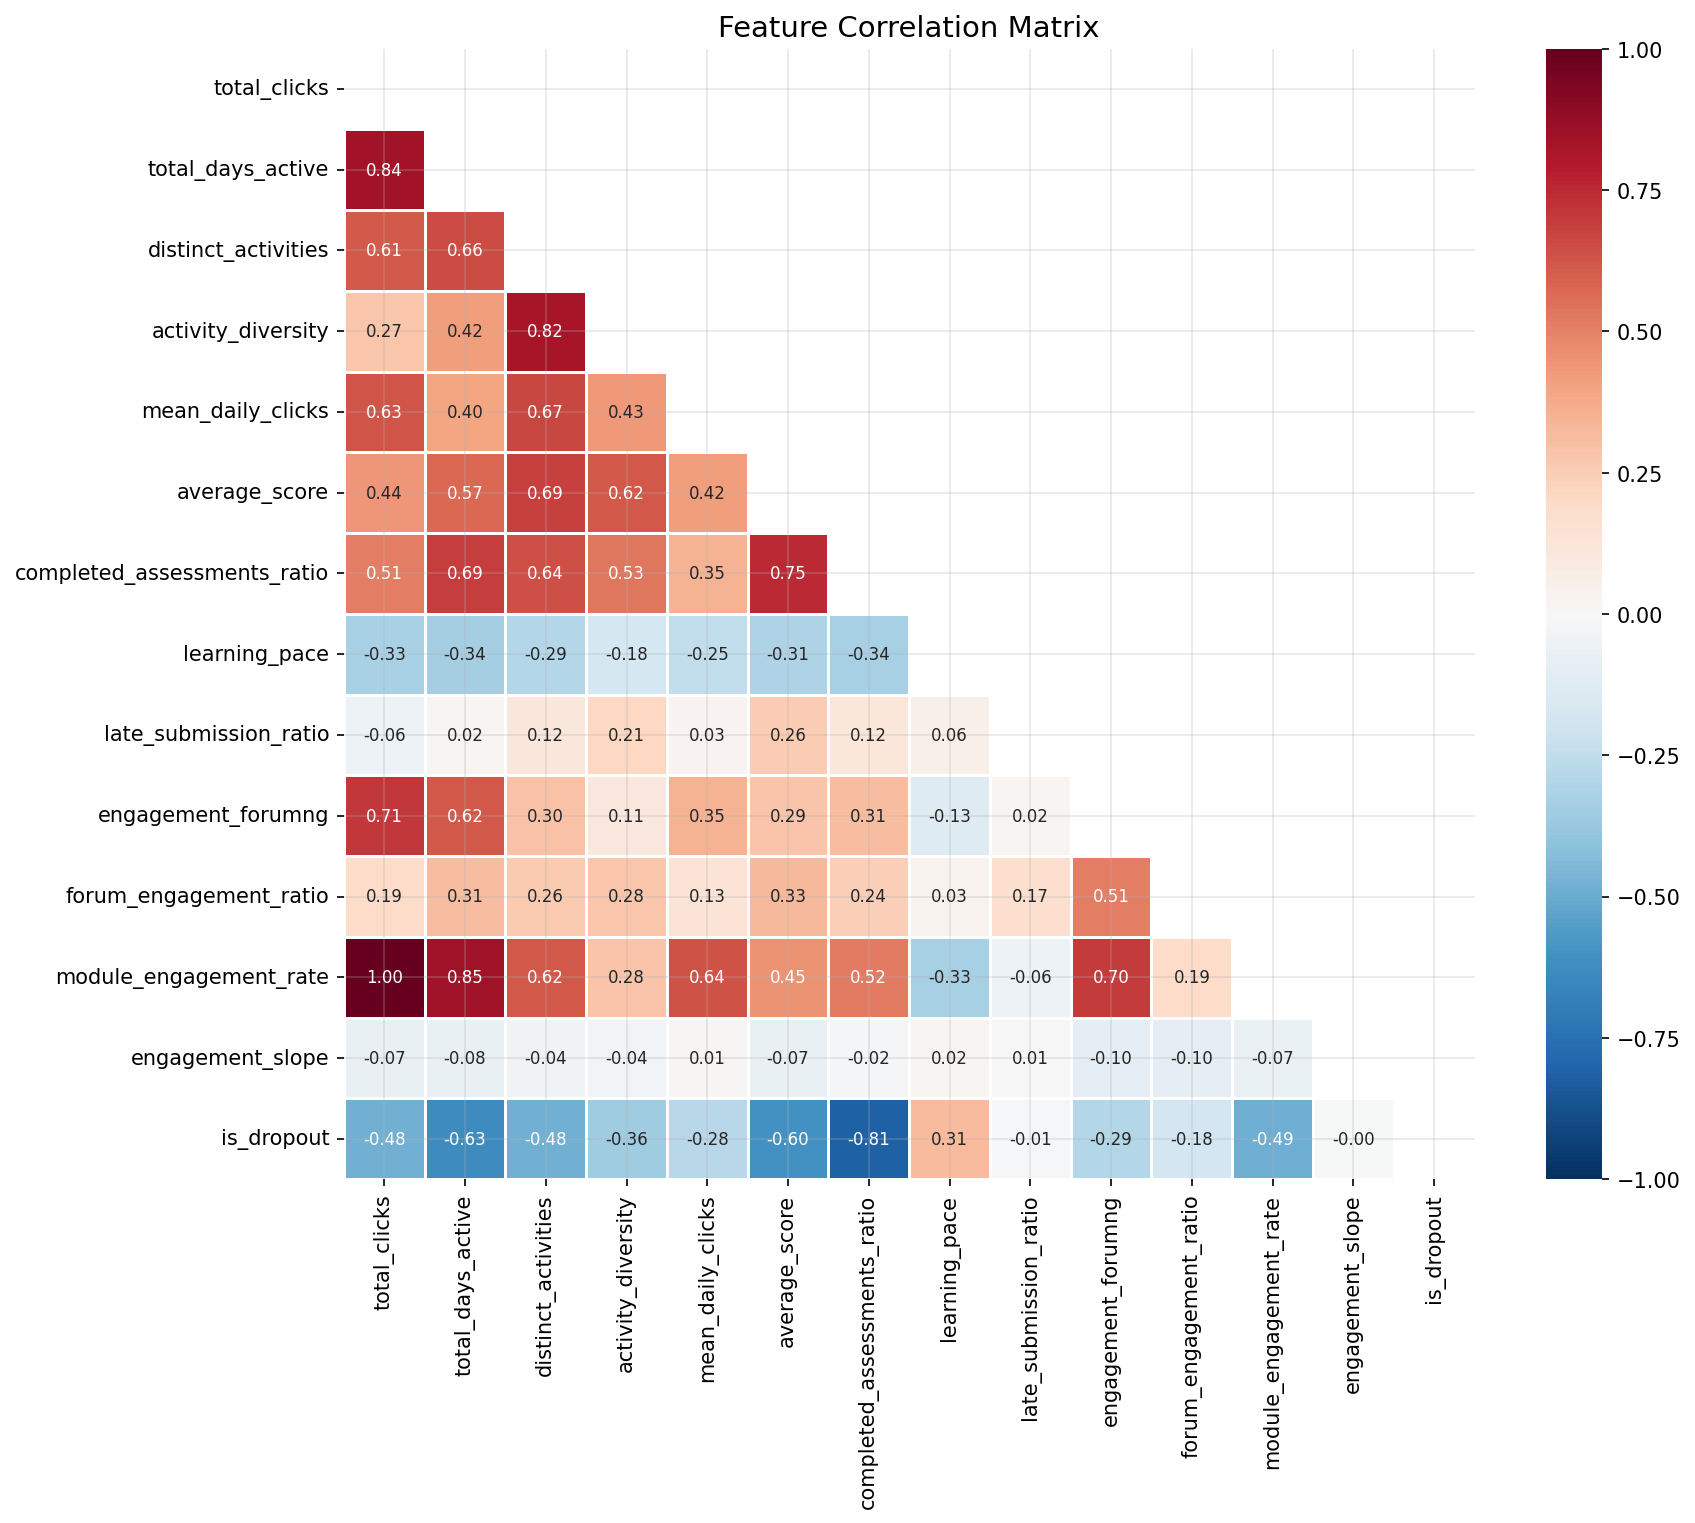

In [7]:
corr_features = available_key + ['is_dropout']
corr_available = [f for f in corr_features if f in features.columns]

fig = plot_correlation_matrix(
    features, corr_available,
    save_path='../results/figures/feature_correlations.png'
)
plt.show()

In [8]:
# Top correlations with target
if 'is_dropout' in features.columns:
    target_corr = features[corr_available].corr()['is_dropout'].drop('is_dropout')
    target_corr = target_corr.abs().sort_values(ascending=False)
    print('Features most correlated with dropout (absolute):')
    for feat, val in target_corr.head(10).items():
        sign = '+' if features[corr_available].corr()['is_dropout'][feat] > 0 else '-'
        print(f'  {feat:35s} {sign}{val:.4f}')

Features most correlated with dropout (absolute):
  completed_assessments_ratio         -0.8132
  total_days_active                   -0.6260
  average_score                       -0.6023
  module_engagement_rate              -0.4860
  distinct_activities                 -0.4827
  total_clicks                        -0.4766
  activity_diversity                  -0.3568
  learning_pace                       +0.3130
  engagement_forumng                  -0.2950
  mean_daily_clicks                   -0.2805


## 2.5 Forum Engagement Analysis

Forum engagement is particularly important for the NLP extension
in Notebook 5. Here we examine the distribution of forum activity
and its relationship to dropout.

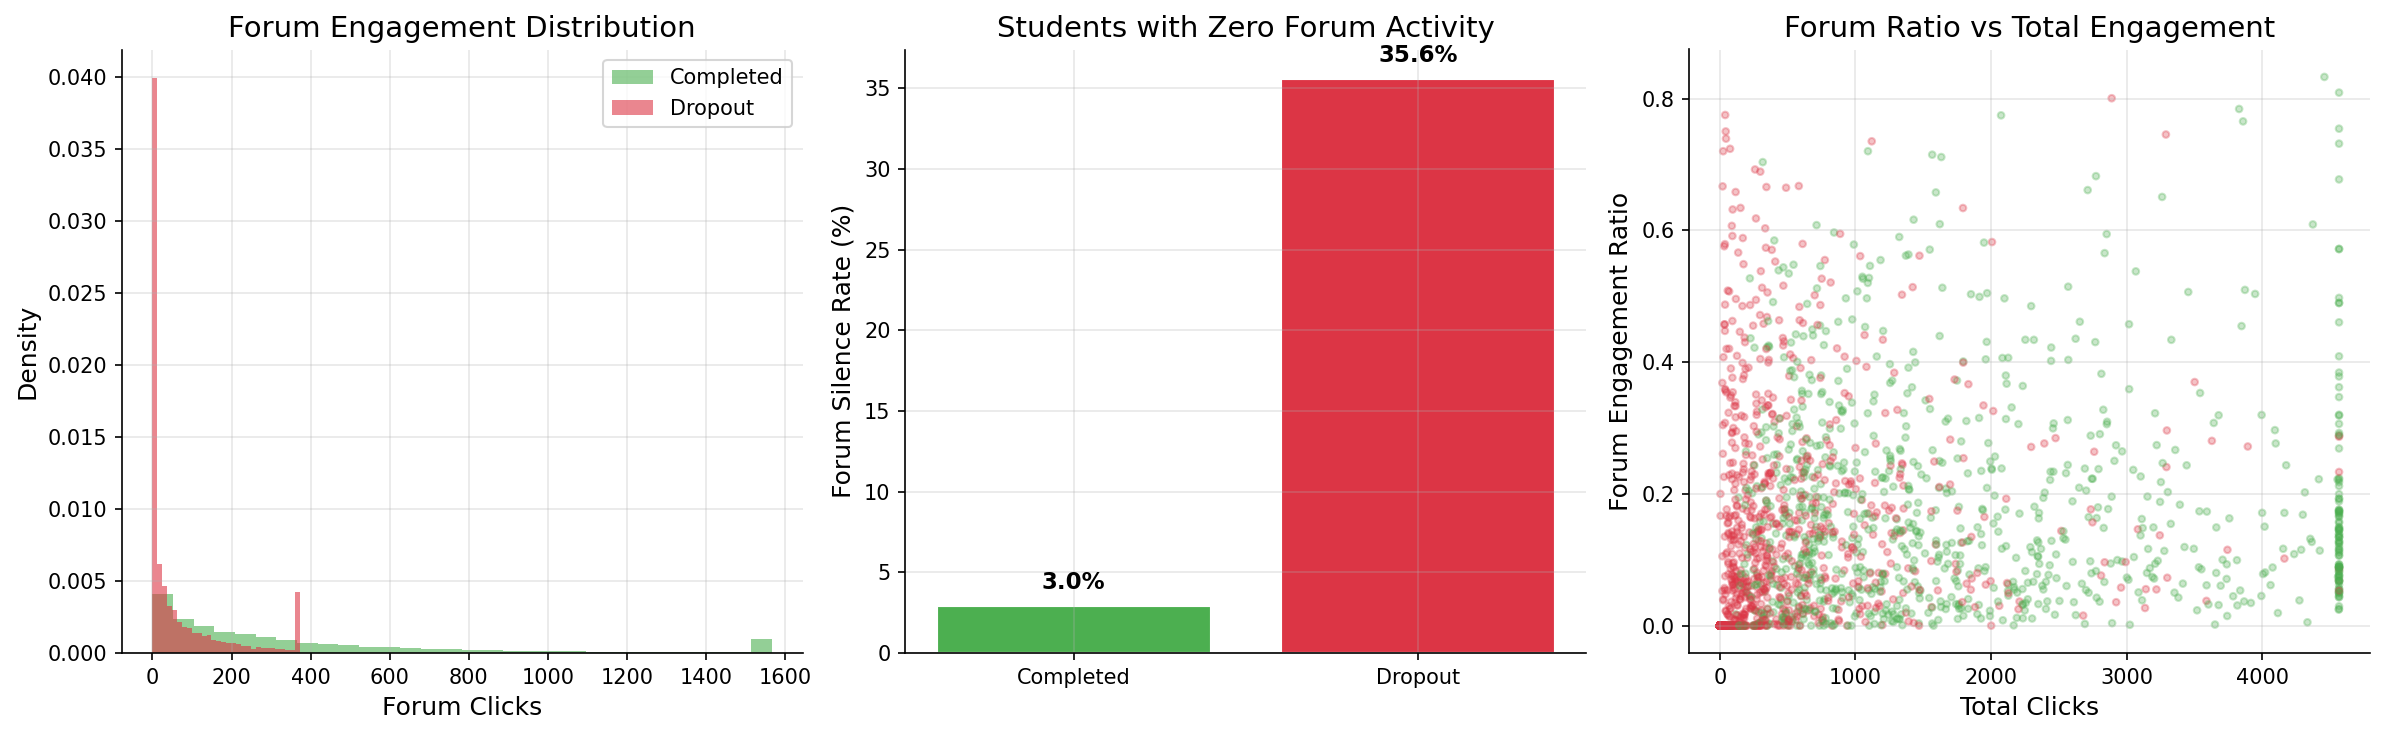

Figure saved: results/figures/forum_analysis.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Forum engagement by outcome
ax = axes[0]
for label, color, name in [(0, COLORS['completed'], 'Completed'),
                            (1, COLORS['dropout'], 'Dropout')]:
    subset = features[features['is_dropout'] == label]['engagement_forumng']
    subset_clipped = subset.clip(upper=subset.quantile(0.95))
    ax.hist(subset_clipped, bins=30, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('Forum Clicks')
ax.set_ylabel('Density')
ax.set_title('Forum Engagement Distribution')
ax.legend()

# Forum silence rate by outcome
ax = axes[1]
silence_by_outcome = features.groupby('is_dropout')['forum_silence'].mean() * 100
bars = ax.bar(['Completed', 'Dropout'], silence_by_outcome.values,
              color=[COLORS['completed'], COLORS['dropout']],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, silence_by_outcome.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Forum Silence Rate (%)')
ax.set_title('Students with Zero Forum Activity')

# Forum ratio vs total engagement
ax = axes[2]
sample = features.sample(min(2000, len(features)), random_state=42)
colors_scatter = [COLORS['dropout'] if d else COLORS['completed']
                  for d in sample['is_dropout']]
ax.scatter(sample['total_clicks'].clip(upper=sample['total_clicks'].quantile(0.95)),
           sample['forum_engagement_ratio'],
           c=colors_scatter, alpha=0.3, s=10)
ax.set_xlabel('Total Clicks')
ax.set_ylabel('Forum Engagement Ratio')
ax.set_title('Forum Ratio vs Total Engagement')

plt.tight_layout()
plt.savefig('../results/figures/forum_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results/figures/forum_analysis.png')

## 2.6 Save Feature Matrix

In [10]:
os.makedirs('../data/processed', exist_ok=True)
features.to_csv('../data/processed/features_complete.csv', index=False)

# Save feature list for downstream use
import json
feature_config = {
    'model_features': model_features,
    'key_features': available_key,
    'target': 'is_dropout',
    'n_students': len(features),
    'n_features': len(model_features),
}
with open('../data/processed/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f'Feature matrix saved: {features.shape[0]:,} students, {len(model_features)} features')
print('Feature config saved: data/processed/feature_config.json')

Feature matrix saved: 32,593 students, 49 features
Feature config saved: data/processed/feature_config.json


## Summary

Key findings from feature engineering:

1. The complete feature set includes engagement, assessment, temporal,
   and registration features, covering both behavioral and demographic
   dimensions.

2. Completed assessments ratio and total clicks are among the strongest
   individual predictors of dropout.

3. Forum engagement shows a clear pattern: dropout students have
   significantly lower forum participation, with a higher rate of
   complete forum silence.

4. Engagement slope (trend over time) captures temporal dynamics that
   static aggregates miss.

Next notebook: Baseline XGBoost model training and evaluation.